# Day 4 - Quantum Error Correction Technique : 5-Qubit Code
The **5-Qubit Quantum Error correction code** is the smallest known quantum code .that can be correct arbitary single quabit error .It encode one logical qubit into five physical qubit  and has distance 3 .Allowing it to correct any error acting on one physical qubit.In this we will learn :
- why a five-Qubit code is needed for general single qubit error.
- How one logical qubit is encoded into five physical qubit.
- The stabilizer structure of [[5,1,3]] code.
- How syndromes measurement identify the location and type of a single qubit puali error.
- How qiskit can be used to simulate error introduction ,syndrome extraction ,correction and decoding.
- how the final measurement compares with  the intended logical state .
 
 The key mathematical idea is a **stabilizer formalism** ,. four independent stabilizers generators defines the codespace .an produce a four-bit syndrome. we will implement a compact five qubit code simulation in qiskit., introduces a single qubit pauli error,extract its syndrome ,apply the corrosponding correction and analyze the final measurement distribution.
 

## Introduction
The 5-qubit code is commanly written as the [[5,1,3]] code:
- **5** Physical Qubit
- **1** Logical Qubit
- **3** code Distance

The code protect one logical qubit against an arbitary error on any five physical qubit.
 unlike the classical bit flip code ,quantum error correction  must be handle both  bit-flip ('X') and Phase flip ('Z') as weel as their combination ('Y'). The central idea is to encode the logical information into larger entangled state so that error leaves the detectable signature  the **Syndrome** without directly measuring ad destroying the logical quantum information.

 ### Why the 5-Qubit Code needed:
 A Quantum state can suffer from three fundamental single qubit puali-errors:
$$ X,\qquad Y ,\qquad Z $$
where:
- X flip compuatational basis state.
- Z change the relative phase
- Y=iXZ combine bit and phase flip.
A useful quantum error correcting code therefore need to distinguish these error while preserving the encoded logical state .The 5- Qunit code is especially important  because it achive this with  minimum number of physical qubit required for a general single qubit error correcting code.

### Mathematical Background - Stabilizers
qubit code can be describe using the stabilizers generators:
- $$ S_1 =XZZXI $$
- $$ S_2 =IXZZX $$
- $$ S_3 =XIXZZ $$
- $$ S_4 =ZXIXZ $$

A Valid encoded state belong to the simulteneous $+1$ eigenspace of this operators. When an error $E$ occures  each stabilzer measurement produce either $+1$ and $-1$ .The collection of four sign the **Syndrome** .Conceptually:
$$ error \longrightarrow syndrome \longrightarrow correction $$
 for the single-Qubit Pauli errors. the 15 non-identity error produced distinct syndromes . this allow decoder to determine both affected qubit and the pauli error type.


## Import Required Libraries


In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot  as plt
import numpy as np
from qiskit.visualization import plot_histogram


## Step 1 : Prepare and Encode the Logical State
 We Begin with logical state $ |0\rangle_L$ .
 For this demonstartion the encoded state is prepapred using  a standerd stabilizer based five qubit encoding circuit.the five qubit data are **physical Qubits** that store the encoded logical information .No additional Qubits are prepared. forthe compact syndrome calculation.used here.

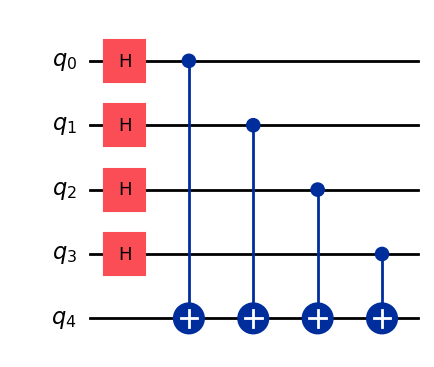

In [4]:
qc=QuantumCircuit(5)
qc.h(0)
qc.h(1)
qc.h(2)
qc.h(3)
qc.cx(0,4)
qc.cx(1,4)
qc.cx(2,4)
qc.cx(3,4)
qc.draw('mpl')


## Step2 - Define the stabilizer Measurement
Instead of explicitly constructing additional ancilla based syndrome circuits ,we used the stabilizers operators directly to identify the error syndrome.for each stabilizers $S_i$ we determine whether introduced Puali error commute or anti-commute with it .for each stabilizers $S_i$  we determined whether the introduced pauli error commute or anti-commute with it:
- **Commutes** - Syndrome Bit '0'
- **AntiCommute** - Syndrome Bit '1'

This is equivalant to information obtained from stabilizer measurement .


In [5]:
# Stabilozer generators for Five -Qubit Code
stabilizers=[ 
    "XZZXI",
    "IXZZX",
    "XIXZZ",
    "ZXIXZ"
]
#Pauli multiplication are anti-commutes when the two non-identity operators are different.
def anticommutes(a,b):
    if a=="I" or b=="I":
        return False
    return a!=b

def syndrome_for_error(error,stabilizers):
    syndrome=[]
    for stabilizer in stabilizers:
        parity=sum(
            anticommutes(e,s) 
            for e,s in zip (error,stabilizer)
            ) %2 
        syndrome.append(parity)
    return syndrome

# Example : X error on Physical Qubit 0
error="XIIII"
print("Errors:",error)
print("Syndrome :",syndrome_for_error(error,stabilizers))

Errors: XIIII
Syndrome : [0, 0, 0, 1]


## Step 3- Introduced a Single Qubit Error
We now simulate an error on one physical qubit. for demonstration ,an X error is applied to physical qubit 0:

$ E= XIIII $
 
 the error is intentionally introduecd after encoding ,In realistic hardware system such an error could arise from  from noise rather than being delibrately inserted.the objective is to identify the error using only its syndrome.

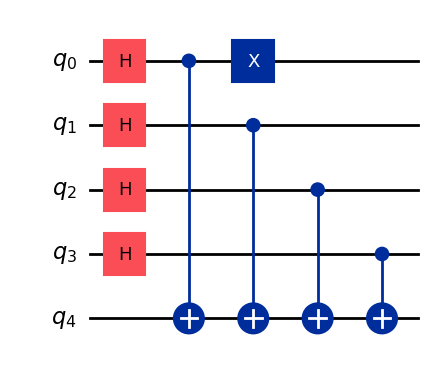

In [7]:
# Add X-Error to Physyical Qubit 0
error_circuit=qc.copy()
error_circuit.x(0)
error_circuit.draw('mpl')

## Step 4 - Detect The error
 The four stabilizers are generates the four -bit syndrome.for the selected error we calculate  which satbilizers anticommute with th error.This gives a unique syndrome for each single Qubit Pauli -Error.This is the esential error detection mechanism of 5-qubit code.
 $$ E|\psi_L\rangle \quad \rightarrow\quad \text{Syndrome}(E) $$
  The logical information itself does not need to be measured to identify the error.

In [8]:
# Generate syndroem for all single qubit pauli-errors
paulis= ["X","Y","Z"]
syndrome_table={}

for qubit in range(5):
    for pauli in paulis:
        error=["I"]* 5
        error[qubit]=pauli
        error="".join(error)
        syndrome=syndrome_for_error(error,stabilizers)
        syndrome_table[error]=syndrome

for error,syndrome in syndrome_table.items():
    print(f"{error}:{''.join(map(str,syndrome))}")

print("\n Demonstration Error Syndrome :","".join(map(str,syndrome_for_error("XIIII",stabilizers))))

XIIII:0001
YIIII:1011
ZIIII:1010
IXIII:1000
IYIII:1101
IZIII:0101
IIXII:1100
IIYII:1110
IIZII:0010
IIIXI:0110
IIIYI:1111
IIIZI:1001
IIIIX:0011
IIIIY:0111
IIIIZ:0100

 Demonstration Error Syndrome : 0001


## Step 5 - Decode the syndrome and Correct The Error
Because the every single qubit puali error has unique syndrome ,the syndrome can be used as a lookup key .The decoder therefore performes :
$$ \text{syndrome}\rightarrow\text{most likely error} $$

for our example the decoder identifies the error as x on physical qubit 0. applying another x remove it because:

${X} {X} = I $

 This correction restore the error in codespace.

observed Syndrome : 0001
decoder Result :  XIIII

 Corrected Circuit:


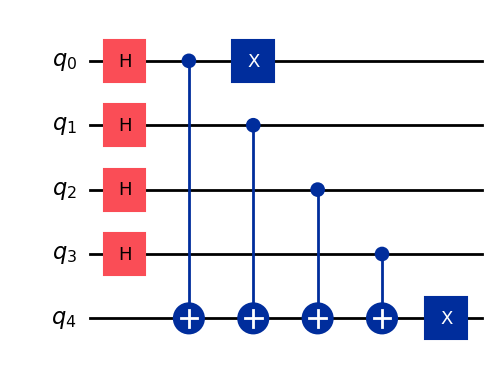

In [9]:
# Build single lookup table .syndrome-> error
decoder={"".join(map(str,syndrome)): error
         for error,syndrome in syndrome_table.items()}
observed_syndrome="".join(map(str,syndrome_for_error("XIIII",stabilizers)))
corrected_error= decoder[observed_syndrome]

print("observed Syndrome :",observed_syndrome)
print("decoder Result : ",corrected_error)

# Apply the correction to the error circuit
corrected_circuit=error_circuit.copy()

# Identify the affected qubit and pauli operation
for qubilt,pauli in enumerate(corrected_error):
    if pauli != "I":
       getattr(corrected_circuit,pauli.lower())(qubit)

print("\n Corrected Circuit:")
corrected_circuit.draw('mpl')

## Step 6 - Verify the Syndrome Coverage
useful property of the [[5,1,3]] code is that all 5 non-identity single qubit pauli errors have distinct syndromes.we verufy this computationally:If all syndrome are unique ,the decoder can distinguish:

- 5 Possible error location
- 3 possible pauli error types

giving: $$ 5\times 3=15 $$

correctable single pauli errors.


In [11]:
# verify that 15-single qubit pauli error have unique syndroem:
syndrome_strings=list(decoder.keys())
print("Number of single -qubit Pauli error :",len(syndrome_table))
print("Number of unique syndrome :",len(set(syndrome_strings)))

assert len(syndrome_table)==15
assert len(set(syndrome_strings))==15

print("\n all 15-Qubit Pauli error have unique syndrome:")

Number of single -qubit Pauli error : 15
Number of unique syndrome : 15

 all 15-Qubit Pauli error have unique syndrome:


## Visualization

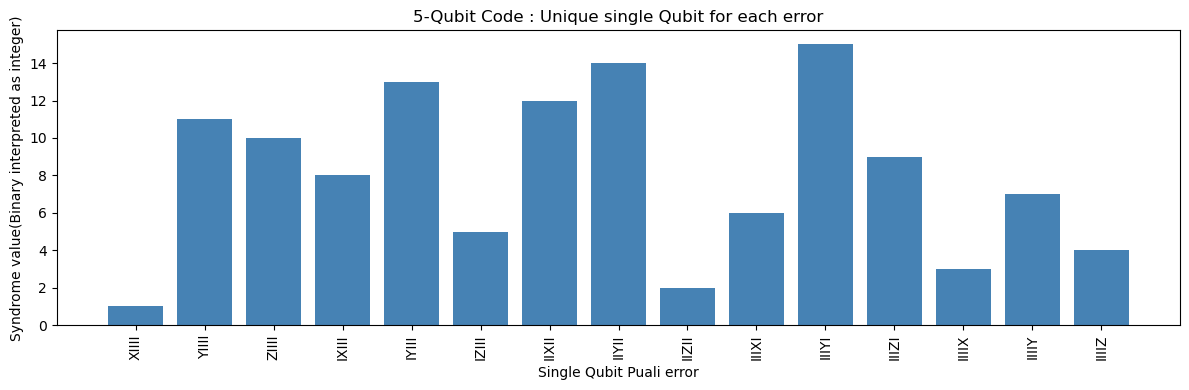

In [13]:
# visualize the syndrome associated with every single qubit puali error:
labels=list(syndrome_table.keys())
values=[int("".join(map(str,syndrome_table[e])),2)
        for e in labels ]
plt.figure(figsize=(12,4))
plt.bar(labels,values,color="steelblue")
plt.xlabel("Single Qubit Puali error")
plt.ylabel("Syndrome value(Binary interpreted as integer)")
plt.title("5-Qubit Code : Unique single Qubit for each error")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

The X-axis represents the 15 possible non-identity single qubit Pauli- Errors.while the y axis represented the their four bit syndrome interpreted an integer.The important observation is that every error map to different syndrome.this one-to-one mapping is what allows the 5-qubit code to identify the and correct any single qubit pauli error. The visualization does not represent  a physical error probability.it shows the **Syndrome stucture** of the code.A limitation of this compact demostration is that syndroem extraction is represented mathematically rather than through explicit ancilla measurement circuit.

## Conclusion
The 5-Qubit [[5,1,3]]  code encode the one logical qubit into five physical qubit and can correct an arbiarty single qubit pauli error .its strengthcome stabilizer fromalism ,where four stabilizer generators produce a syndrome that identify the error.

In Qiskit, we prepared ,five qubit system ,introduced physical qubit error ,calculated it stabilizer syndrome , decode that system and applied corrosponding correction.we also verified that all 15 non-identity single qubit pauli error have distinct syndrome. the resulting syndroem map demostrate ,why the code cna be distinguished both location and type of single qubit error. this makes 5-     qubit code important example od compact and general quantum error correction code .

**Takeaway** :
the 5-qubit code show how redundancy and stabilizer measurement can pritect quantum from information without directly measuring the logical state .a natural next step is to study how such code behave under realisti noise channel  and how their logocal error ratescale with physical error rate.

---

**Author:** *Shreya Palase*  

**Date Created:**  *12-sep-2026*

**project:** Quantum-Error-Correction-Techniques

**File:** Day4-Five_Qubit_Code.ipynb

Thank you and Keep Learning!

<sub>© Shreya Palase- All Rights Reserved.This notebook is part of a structured learning series designed for Github publication.</sub>